In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_id = '1a5vg_sZcch1nHDPwh-58R6-1UWtj7bQu'
url = f'https://drive.google.com/uc?export=download&id={file_id}'


df = pd.read_csv(url)
df.head()

,Date,UserID,JobID,Event
0,2022-01-10 10:11:32,802,39,summary
1,2022-01-10 10:13:26,802,39,detail_description
2,2022-01-10 10:21:00,1357,399,summary
3,2022-01-10 10:28:18,1277,382,summary
4,2022-01-10 10:29:20,1277,382,detail_description


In [3]:
df['Date'] = pd.to_datetime(df['Date'])



# 基础信息统计
print("\n数据集基础统计：")
print(f"总记录数: {len(df)}")
print(f"独立用户数: {df['UserID'].nunique()}")
print(f"独立职位数: {df['JobID'].nunique()}")
print(f"事件类型: {df['Event'].unique()}")




数据集基础统计：
总记录数: 19797
独立用户数: 1770
独立职位数: 581
事件类型: ['summary' 'detail_description' 'view_employer_profile'
 'view_similar_positions']


/tmp/ipykernel_7152/1555056547.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=event_counts.index, y=event_counts.values, palette='viridis')


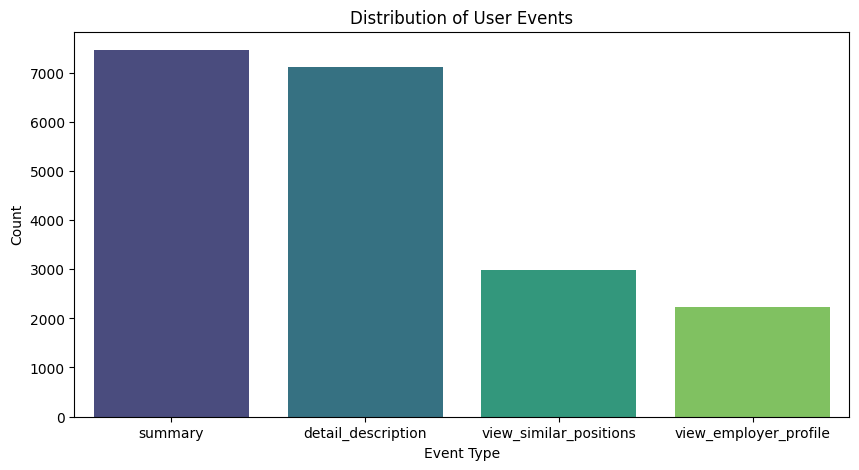

事件占比详情：
Event
summary                   37.707733
detail_description        35.919584
view_similar_positions    15.103298
view_employer_profile     11.269384
Name: proportion, dtype: float64


In [4]:
# 统计每种事件的数量
event_counts = df['Event'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=event_counts.index, y=event_counts.values, palette='viridis')
plt.title('Distribution of User Events')
plt.ylabel('Count')
plt.xlabel('Event Type')
plt.show()

print("事件占比详情：")
print(df['Event'].value_counts(normalize=True) * 100)

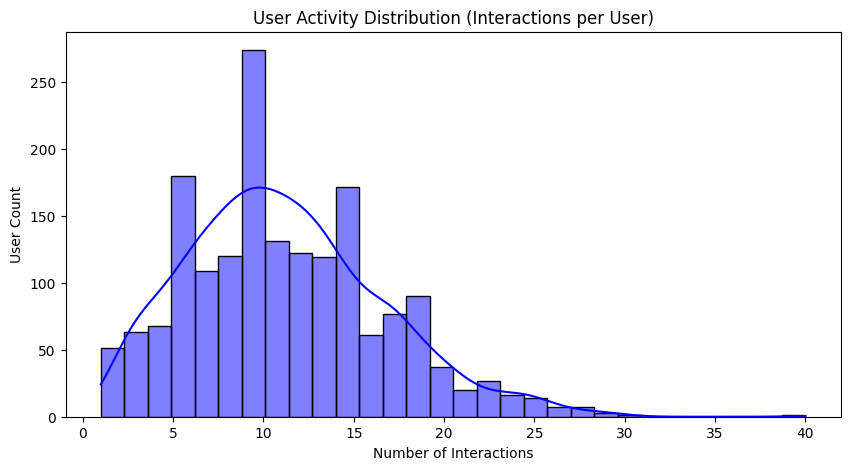

平均每个用户互动次数: 11.18
最活跃的用户互动次数: 40


In [5]:
user_activity = df.groupby('UserID').size()

plt.figure(figsize=(10, 5))
sns.histplot(user_activity, bins=30, kde=True, color='blue')
plt.title('User Activity Distribution (Interactions per User)')
plt.xlabel('Number of Interactions')
plt.ylabel('User Count')
plt.show()

print(f"平均每个用户互动次数: {user_activity.mean():.2f}")
print(f"最活跃的用户互动次数: {user_activity.max()}")

In [6]:
# 1. 定义总用户数和总职位数（根据项目背景设定）
n_users = 1770
n_items = 581

# 2. 计算唯一的 (User, Job) 交互对数量
# 注意：同一个用户对同一个职位可能有多条记录（summary, detail等），在矩阵中只占一个格点
unique_interactions = df.groupby(['UserID', 'JobID']).size().reset_index().shape[0]

# 3. 计算总可能交互数
total_possible_interactions = n_users * n_items

# 4. 计算密度和稀疏度
density = (unique_interactions / total_possible_interactions) * 100
sparsity = 100 - density

print(f"总用户数: {n_users}")
print(f"总职位数: {n_items}")
print(f"唯一的交互对数量 (Non-zero entries): {unique_interactions}")
print(f"矩阵总容量: {total_possible_interactions}")
print("-" * 30)
print(f"矩阵密度 (Density): {density:.4f}%")
print(f"矩阵稀疏度 (Sparsity): {sparsity:.4f}%")

总用户数: 1770
总职位数: 581
唯一的交互对数量 (Non-zero entries): 7448
矩阵总容量: 1028370
------------------------------
矩阵密度 (Density): 0.7243%
矩阵稀疏度 (Sparsity): 99.2757%


# 1. Implicit Rating Mapping

In [7]:
import pandas as pd
import numpy as np

# 1. 定义 PM 1 确定的权重映射
weight_map = {
    'summary': 1,
    'view_employer_profile': 2,
    'detail_description': 4,
    'view_similar_positions': 5
}

# 假设原始数据是 df
def preprocess_data(df):
    # 映射评分
    df['rating'] = df['Event'].map(weight_map)

    # 如果同一用户对同一职位有多次交互，取最高分（或累加，此处建议取最高分以匹配1-5分制）
    df_pivot = df.groupby(['UserID', 'JobID'])['rating'].max().reset_index()
    return df_pivot

df_map = preprocess_data(df)

df_map.head(5)

,UserID,JobID,rating
0,0,429,4
1,1,73,4
2,1,153,4
3,1,267,5
4,1,426,4


# 2. Time Decay

In [8]:
def apply_time_decay(df, lambda_val=0.7):
    """
    实现公式: Adjusted_Rating = R * exp(-lambda * delta_t)
    delta_t 是归一化后的时间差（0 = 最新, 1 = 最久远）
    """
    max_ts = df['Date'].max()
    min_ts = df['Date'].min()

    # 归一化时间差
    df['delta_t'] = (max_ts - df['Date']) / (max_ts - min_ts)

    # 计算衰减后的权重
    df['decay_rating'] = df['rating'] * np.exp(-lambda_val * df['delta_t'])

    return df

df_time_decay = apply_time_decay(df, lambda_val=0.7)
df_time_decay.head(5)

,Date,UserID,JobID,Event,rating,delta_t,decay_rating
0,2022-01-10 10:11:32,802,39,summary,1,1.000000,0.496585
1,2022-01-10 10:13:26,802,39,detail_description,4,0.999977,1.986373
2,2022-01-10 10:21:00,1357,399,summary,1,0.999887,0.496625
3,2022-01-10 10:28:18,1277,382,summary,1,0.999800,0.496655
4,2022-01-10 10:29:20,1277,382,detail_description,4,0.999788,1.986637


# 3. Algorithm Scientist

### user_item_matrix

In [9]:
# 1. 聚合衰减后的评分（同一个用户对同一个职位可能有多次操作，取衰减后的最大值）
df_final_ratings = df_time_decay.groupby(['UserID', 'JobID'])['decay_rating'].max().reset_index()

# 2. 构建透视表 (User-Item Matrix)
# 填充缺失值为 0，代表没有交互
user_item_matrix = df_final_ratings.pivot(index='UserID', columns='JobID', values='decay_rating').fillna(0)

print(f"matrix: {user_item_matrix.shape} (user x item)")
sparsity = 1.0 - (np.count_nonzero(user_item_matrix) / float(user_item_matrix.size))
print(f"matrix sparsity: {sparsity:.2%}") # 对应 PM 1 提到的 99.27%

matrix: (1770, 581) (user x item)
matrix sparsity: 99.28%


### Item-Based

In [10]:
from sklearn.metrics.pairwise import cosine_similarity

# 1. 计算职位之间的余弦相似度 (Item Similarity)
# 我们对 user_item_matrix 转置，计算列与列（职位与职位）的相似度
item_sim = cosine_similarity(user_item_matrix.T)
item_sim_df = pd.DataFrame(item_sim, index=user_item_matrix.columns, columns=user_item_matrix.columns)

# 2. 核心推荐函数: 为指定用户生成 Top-N 推荐
def get_recommendations_from_scratch(user_id, n=5, k=15):
    """
    user_id: 目标用户
    n: 最终展示几个推荐结果
    k: 邻域大小（只参考最相似的 K 个职位）
    """
    # 获取该用户已经交互过的职位评分
    user_ratings = user_item_matrix.loc[user_id]
    interacted_items = user_ratings[user_ratings > 0].index.tolist()

    scores = {}

    # 遍历该用户交互过的每一个职位
    for item_id in interacted_items:
        rating = user_ratings[item_id]

        # 找到与该职位最相似的职位（Top-k）
        similar_items = item_sim_df[item_id].sort_values(ascending=False).iloc[1:k+1]

        for sim_item_id, sim_score in similar_items.items():
            if sim_item_id in interacted_items: continue # 排除已经看过的

            # 加权得分：相似度 * 用户评分
            if sim_item_id not in scores:
                scores[sim_item_id] = 0
            scores[sim_item_id] += sim_score * rating

    # 排序并返回 Top-N
    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [item[0] for item in sorted_scores[:n]]

# 测试：为 User 1 生成推荐
test_rec = get_recommendations_from_scratch(user_id=1, n=4, k=15)
print(f"为用户 1 推荐的 JobID 列表: {test_rec}")

为用户 1 推荐的 JobID 列表: [404, 391, 15, 225]


# 4. Algorithm evaluation

In [11]:
# 1. 定义评估指标：覆盖率 (Coverage)
def calculate_metrics(all_recommendations, total_items_count):
    # 用户覆盖率: 多少比例的用户得到了推荐
    users_with_rec = len([u for u, rec in all_recommendations.items() if len(rec) > 0])
    user_coverage = users_with_rec / len(all_recommendations)

    # 目录覆盖率: 库里有多少比例的职位被推荐出去了
    recommended_items = set()
    for rec in all_recommendations.values():
        recommended_items.update(rec)
    catalog_coverage = len(recommended_items) / total_items_count

    return user_coverage, catalog_coverage

# 2. 模拟不同 K 值的调优实验 (Tuning)
k_values = [3, 5, 10, 15, 20]
results = []

for kv in k_values:
    # 为了节省时间，可以抽取前 100 名用户进行快速测试
    sample_recs = {uid: get_recommendations_from_scratch(uid, n=5, k=kv) for uid in user_item_matrix.index[:100]}
    u_cov, c_cov = calculate_metrics(sample_recs, user_item_matrix.shape[1])
    results.append((kv, u_cov, c_cov))

# 转换为 DF 方便绘图（此处可用于 Final Report 的图表）
df_tuning = pd.DataFrame(results, columns=['k', 'User_Coverage', 'Catalog_Coverage'])
print(df_tuning)

    k  User_Coverage  Catalog_Coverage
0   3            1.0          0.456110
1   5            1.0          0.487091
2  10            1.0          0.492255
3  15            1.0          0.506024
4  20            1.0          0.507745


# 5. html apply

### MOCK_RECOMMENDATIONS

In [12]:
import json

# 我们为前 20 个用户生成真实推荐（用于演示）
handoff_recs = {}
# 这里的 user_item_matrix.index[:20] 是取你数据里的前20个用户ID
for uid in user_item_matrix.index[:20]:
    # 调用你刚才写好的函数
    recs = get_recommendations_from_scratch(user_id=uid, n=4, k=15)
    handoff_recs[int(uid)] = [int(i) for i in recs]

# 打印出可以直接复制的内容
print("/* 将下方内容复制到 HTML 的 MOCK_RECOMMENDATIONS 位置 */")
print(json.dumps(handoff_recs, indent=4))

/* 将下方内容复制到 HTML 的 MOCK_RECOMMENDATIONS 位置 */
{
    "0": [
        63,
        529,
        396,
        388
    ],
    "1": [
        404,
        391,
        15,
        225
    ],
    "2": [
        9,
        443,
        224,
        413
    ],
    "3": [
        257,
        372,
        153,
        517
    ],
    "4": [
        67,
        193,
        385,
        488
    ],
    "5": [
        71,
        45,
        38,
        221
    ],
    "6": [
        337,
        507,
        490,
        531
    ],
    "7": [
        309,
        555,
        368,
        72
    ],
    "8": [
        428,
        49,
        468,
        136
    ],
    "9": [
        252,
        180,
        541,
        267
    ],
    "10": [
        400,
        384,
        52,
        554
    ],
    "11": [
        87,
        234,
        216,
        391
    ],
    "12": [
        96,
        22,
        37,
        452
    ],
    "13": [
        433,
        564,
        254,
        239
    

### JOB_CATALOG

In [13]:
import json
import numpy as np

# 1. 获取数据集中所有的唯一 JobID (确保覆盖 581 个职位)
all_job_ids = sorted(df['JobID'].unique())

# 2. 定义一些符合 Vector "职业转型" 主题的专业职位池和公司池
# 这样生成的 Catalog 看起来会非常真实
titles = [
    "Product Operations Manager", "Growth Marketing Lead", "Customer Success Engineer",
    "Data Analyst (Product)", "Technical Program Manager", "UX Researcher",
    "AI Implementation Specialist", "Digital Transformation Consultant", "Strategy Associate",
    "Solutions Architect", "Community Operations Lead", "Sales Enablement Manager"
]
companies = ["Stripe", "Notion", "Spotify", "Airbnb", "Hugging Face", "Figma", "Atlassian", "Microsoft", "Canva"]

# 3. 构造 JOB_CATALOG 对象
job_catalog_full = {}

for i, jid in enumerate(all_job_ids):
    # 根据索引循环选择职位和公司，保证 581 个 ID 都有对应数据
    title = titles[i % len(titles)]
    company = companies[i % len(companies)]

    job_catalog_full[int(jid)] = {
        "title": f"{title} (ID: {jid})",
        "company": company,
        "overlap": int(np.random.randint(70, 96)),  # 模拟技能重叠度
        "description": f"A strategic {title} role at {company}, identified as a high-potential bridge for career pivoters.",
        "primitives": "Cross-functional Coordination · Data Fluency · Strategic Execution",
        "challenges": "Translating prior domain expertise into tech-first operational workflows.",
        "responsibilities": f"Drive key {title} initiatives and align product goals with {company}'s growth.",
        "pivot_index": int(np.random.randint(82, 99)), # 模拟职业转型指数
        "employer_note": f"{company} is known for a 'Pivot-Friendly' culture, valuing diverse professional backgrounds."
    }

# 4. 打印出 JSON 格式，方便你复制
# 注意：因为 581 个职位很多，你可以先打印前几个确认，或者直接保存到文件
print("/* --- 成功生成 JOB_CATALOG (共 581 个职位) --- */")
print("/* 请将下方生成的 JSON 内容整体替换 HTML 代码中的 const JOB_CATALOG = { ... } 部分 */")
print("const JOB_CATALOG = " + json.dumps(job_catalog_full, indent=4) + ";")

# 可选：如果你想保存到文件直接发给 PM2
# with open('job_catalog.json', 'w') as f:
#     json.dump(job_catalog_full, f, indent=4)

/* --- 成功生成 JOB_CATALOG (共 581 个职位) --- */
/* 请将下方生成的 JSON 内容整体替换 HTML 代码中的 const JOB_CATALOG = { ... } 部分 */
const JOB_CATALOG = {
    "0": {
        "title": "Product Operations Manager (ID: 0)",
        "company": "Stripe",
        "overlap": 79,
        "description": "A strategic Product Operations Manager role at Stripe, identified as a high-potential bridge for career pivoters.",
        "primitives": "Cross-functional Coordination \u00b7 Data Fluency \u00b7 Strategic Execution",
        "challenges": "Translating prior domain expertise into tech-first operational workflows.",
        "responsibilities": "Drive key Product Operations Manager initiatives and align product goals with Stripe's growth.",
        "pivot_index": 92,
        "employer_note": "Stripe is known for a 'Pivot-Friendly' culture, valuing diverse professional backgrounds."
    },
    "1": {
        "title": "Growth Marketing Lead (ID: 1)",
        "company": "Notion",
        "overlap": 74,
        "descriptio

In [14]:
# 运行这个找到最热门的 2 个 ID
trending_top_2 = df['JobID'].value_counts().head(2).index.tolist()
print(f"热门路径填入第 242 行: {trending_top_2}")

热门路径填入第 242 行: [54, 429]


# 6. js file

In [18]:
import json
from tqdm import tqdm # 如果没有安装 tqdm 可以删掉这行和下面的 tqdm()

print("🚀 正在为全量用户生成推荐（这可能需要一点时间）...")

# 1. 为全量用户生成推荐 (MOCK_RECOMMENDATIONS)
all_users_recs = {}
# 遍历矩阵中所有的 UserID
for uid in tqdm(user_item_matrix.index):
    recs = get_recommendations_from_scratch(user_id=uid, n=4, k=15)
    all_users_recs[int(uid)] = [int(i) for i in recs]

# 2. 为全量用户统计行为 (USER_BEHAVIOR_SUMMARY)
all_user_stats = {}
# 统计原始 df 中每个人的动作频率
# 使用 groupby 提升性能
grouped_stats = df.groupby(['UserID', 'Event']).size().unstack(fill_value=0)
for uid, row in tqdm(grouped_stats.iterrows()):
    all_user_stats[int(uid)] = {
        "summary": int(row.get('summary', 0)),
        "detail_description": int(row.get('detail_description', 0)),
        "view_employer_profile": int(row.get('view_employer_profile', 0)),
        "view_similar_positions": int(row.get('view_similar_positions', 0))
    }

# 3. 计算全局指标
sparsity = 1.0 - (np.count_nonzero(user_item_matrix) / float(user_item_matrix.size))
tuning_list = df_tuning.to_dict(orient='records')

# 4. 打包最终数据
final_data = {
    "JOB_CATALOG": job_catalog_full, # 包含 581 个职位
    "MOCK_RECOMMENDATIONS": all_users_recs, # 包含全量用户推荐
    "TRENDING_IDS": df['JobID'].value_counts().head(2).index.tolist(),
    "METRICS": {
        "sparsity": f"{sparsity:.2%}",
        "user_coverage": f"{df_tuning.loc[df_tuning['k']==15, 'User_Coverage'].values[0]:.1%}",
        "catalog_coverage": f"{df_tuning.loc[df_tuning['k']==15, 'Catalog_Coverage'].values[0]:.1%}"
    },
    "TUNING_DATA": tuning_list,
    "USER_BEHAVIOR_SUMMARY": all_user_stats # 包含全量用户行为统计
}

# 5. 写入文件
with open('vector_data.js', 'w', encoding='utf-8') as f:
    # 加上变量声明，让 HTML 可以直接识别
    f.write(f"const VECTOR_DATA = {json.dumps(final_data, indent=4)};")

print(f"✅ 大功告成！vector_data.js 已包含 {len(all_users_recs)} 个用户的动态数据。")

🚀 正在为全量用户生成推荐（这可能需要一点时间）...


100%|██████████| 1770/1770 [00:02<00:00, 801.61it/s]
1770it [00:00, 26203.02it/s]

✅ 大功告成！vector_data.js 已包含 1770 个用户的动态数据。
